# NB14 — Custo Estimado de TEsperaAtracacao por Carrier · Brasil 2025

**Objetivo:** Monetizar a TEsperaAtracacao mediana por carrier usando vessel cost/day de referência  
ponderado pelo mix de vessel_segment real de cada carrier no mercado brasileiro.

**Inputs:** KPIs NB10 (TEspera, escalas) · Distribuição de segmento NB10 · Premissas Clarksons/BIMCO 2024/2025  
**Natureza:** Estimativa de ordem de grandeza — não são custos auditados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

FIG_DIR = '../outputs/figures/'
CSV_DIR = '../outputs/processed_data/'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


---
## 1 — Premissas e Dados de Input

In [2]:
# ── Vessel cost/day por segmento (USD · referência Clarksons/BIMCO 2024/2025) ──
VESSEL_COST_DAY = {
    'Feeder Max (1k-3k TEU)':     15_000,
    'Sub-Panamax (3k-8k TEU)':    25_000,
    'Post-Panamax (8k-12k TEU)':  40_000,
    'New Panamax (12k-18k TEU)':  55_000,
    'Ultra Large (> 18k TEU)':    80_000,
}

# ── KPIs por carrier (NB10 · LC Longo Curso 2025) ─────────────────────────
# TEsperaAtracacao = mediana em horas; escalas = nº escalas LC anuais
carrier_kpis = pd.DataFrame([
    {'CARRIER': 'MAERSK',      'TEspera_h': 4.80,  'N_Escalas': 311},
    {'CARRIER': 'CMA CGM',     'TEspera_h': 4.37,  'N_Escalas':  84},
    {'CARRIER': 'MSC',         'TEspera_h': 11.45, 'N_Escalas': 169},
    {'CARRIER': 'Hapag-Lloyd', 'TEspera_h': 9.46,  'N_Escalas': 121},
    {'CARRIER': 'COSCO',       'TEspera_h': 16.19, 'N_Escalas': 156},
    {'CARRIER': 'EVERGREEN',   'TEspera_h': 19.60, 'N_Escalas': 100},
])

# ── Distribuição de vessel_segment por carrier ────────────────────────────
# Calculada a partir do join Atracacao 2025 × Vessels_Master_Enriched (LC)
# % das escalas identificadas por segmento
seg_dist = pd.DataFrame([
    # carrier, Feeder Max, Sub-Panamax, Post-Panamax, New Panamax, ULCV
    {'CARRIER': 'MAERSK',      'Feeder Max (1k-3k TEU)':  7.3, 'Sub-Panamax (3k-8k TEU)': 74.3, 'Post-Panamax (8k-12k TEU)': 15.2, 'New Panamax (12k-18k TEU)':  3.1, 'Ultra Large (> 18k TEU)': 0.0},
    {'CARRIER': 'CMA CGM',     'Feeder Max (1k-3k TEU)': 78.8, 'Sub-Panamax (3k-8k TEU)': 10.0, 'Post-Panamax (8k-12k TEU)':  7.5, 'New Panamax (12k-18k TEU)':  3.8, 'Ultra Large (> 18k TEU)': 0.0},
    {'CARRIER': 'MSC',         'Feeder Max (1k-3k TEU)':  0.0, 'Sub-Panamax (3k-8k TEU)':  3.2, 'Post-Panamax (8k-12k TEU)': 75.2, 'New Panamax (12k-18k TEU)': 17.8, 'Ultra Large (> 18k TEU)': 3.8},
    {'CARRIER': 'Hapag-Lloyd', 'Feeder Max (1k-3k TEU)':  0.0, 'Sub-Panamax (3k-8k TEU)': 53.0, 'Post-Panamax (8k-12k TEU)': 45.5, 'New Panamax (12k-18k TEU)':  0.0, 'Ultra Large (> 18k TEU)': 1.5},
    {'CARRIER': 'COSCO',       'Feeder Max (1k-3k TEU)':  0.0, 'Sub-Panamax (3k-8k TEU)': 81.0, 'Post-Panamax (8k-12k TEU)': 11.0, 'New Panamax (12k-18k TEU)':  8.0, 'Ultra Large (> 18k TEU)': 0.0},
    {'CARRIER': 'EVERGREEN',   'Feeder Max (1k-3k TEU)': 15.0, 'Sub-Panamax (3k-8k TEU)':  0.0, 'Post-Panamax (8k-12k TEU)': 20.0, 'New Panamax (12k-18k TEU)': 60.0, 'Ultra Large (> 18k TEU)': 5.0},
])

SEG_COLS = list(VESSEL_COST_DAY.keys())

print('Premissas de vessel cost/day (USD · referência Clarksons/BIMCO 2024/2025):')
for seg, cost in VESSEL_COST_DAY.items():
    print(f'  {seg:30s}  USD {cost:,}/day')
print()
print('KPIs por carrier (NB10):')
print(carrier_kpis.to_string(index=False))
print()
print('Distribuição vessel_segment por carrier (% escalas identificadas):')
print(seg_dist.set_index('CARRIER').round(1).to_string())

Premissas de vessel cost/day (USD · referência Clarksons/BIMCO 2024/2025):
  Feeder Max (1k-3k TEU)          USD 15,000/day
  Sub-Panamax (3k-8k TEU)         USD 25,000/day
  Post-Panamax (8k-12k TEU)       USD 40,000/day
  New Panamax (12k-18k TEU)       USD 55,000/day
  Ultra Large (> 18k TEU)         USD 80,000/day

KPIs por carrier (NB10):
    CARRIER  TEspera_h  N_Escalas
     MAERSK       4.80        311
    CMA CGM       4.37         84
        MSC      11.45        169
Hapag-Lloyd       9.46        121
      COSCO      16.19        156
  EVERGREEN      19.60        100

Distribuição vessel_segment por carrier (% escalas identificadas):
             Feeder Max (1k-3k TEU)  Sub-Panamax (3k-8k TEU)  Post-Panamax (8k-12k TEU)  New Panamax (12k-18k TEU)  Ultra Large (> 18k TEU)
CARRIER                                                                                                                                    
MAERSK                          7.3                     74.3        

---
## 2 — Cálculo do Vessel Cost/Day Ponderado

In [3]:
# ── Vessel cost/day médio ponderado pelo mix de segmentos ─────────────────
def weighted_cost(row):
    total_pct = sum(row[s] for s in SEG_COLS)
    if total_pct == 0:
        return np.nan
    return sum(row[s] / 100 * VESSEL_COST_DAY[s] for s in SEG_COLS)

seg_dist['VesselCost_Day_USD'] = seg_dist.apply(weighted_cost, axis=1).round(0)

print('Vessel cost/day ponderado por carrier:')
cost_table = seg_dist[['CARRIER','VesselCost_Day_USD']].copy()
for _, row in cost_table.iterrows():
    # Show breakdown
    seg_row = seg_dist[seg_dist['CARRIER'] == row['CARRIER']].iloc[0]
    breakdown = ' + '.join(
        f"{seg_row[s]:.0f}%×${VESSEL_COST_DAY[s]//1000}k"
        for s in SEG_COLS if seg_row[s] > 0
    )
    print(f"  {row['CARRIER']:12s}  USD {row['VesselCost_Day_USD']:,.0f}/day  [{breakdown}]")

Vessel cost/day ponderado por carrier:
  MAERSK        USD 27,455/day  [7%×$15k + 74%×$25k + 15%×$40k + 3%×$55k]
  CMA CGM       USD 19,410/day  [79%×$15k + 10%×$25k + 8%×$40k + 4%×$55k]
  MSC           USD 43,710/day  [3%×$25k + 75%×$40k + 18%×$55k + 4%×$80k]
  Hapag-Lloyd   USD 32,650/day  [53%×$25k + 46%×$40k + 2%×$80k]
  COSCO         USD 29,050/day  [81%×$25k + 11%×$40k + 8%×$55k]
  EVERGREEN     USD 47,250/day  [15%×$15k + 20%×$40k + 60%×$55k + 5%×$80k]


---
## 3 — Custo por Escala e Custo Anual

In [4]:
# ── Merge KPIs + vessel cost ──────────────────────────────────────────────
result = carrier_kpis.merge(
    seg_dist[['CARRIER', 'VesselCost_Day_USD']],
    on='CARRIER', how='left'
)

# ── Custo por escala (USD) ─────────────────────────────────────────────────
# Custo por escala = TEspera_mediana (h) / 24 × VesselCost_Day
result['CustoPorEscala_USD'] = (result['TEspera_h'] / 24 * result['VesselCost_Day_USD']).round(0)

# ── Custo anual estimado (USD) ─────────────────────────────────────────────
result['CustoAnual_USD']   = (result['CustoPorEscala_USD'] * result['N_Escalas']).round(0)
result['CustoAnual_MUSD']  = (result['CustoAnual_USD'] / 1_000_000).round(2)

# ── Total de mercado ───────────────────────────────────────────────────────
total_musd = result['CustoAnual_MUSD'].sum()
total_usd  = result['CustoAnual_USD'].sum()

# Ordenar por custo anual
result = result.sort_values('CustoAnual_USD', ascending=False).reset_index(drop=True)

print('=== Custo Estimado de TEsperaAtracacao por Carrier · Brasil 2025 ===')
print()
display_cols = ['CARRIER','TEspera_h','N_Escalas','VesselCost_Day_USD','CustoPorEscala_USD','CustoAnual_USD','CustoAnual_MUSD']
print(result[display_cols].rename(columns={
    'VesselCost_Day_USD':  'Cost_Day_USD',
    'CustoPorEscala_USD':  'Custo/Escala_USD',
    'CustoAnual_USD':      'Custo_Anual_USD',
    'CustoAnual_MUSD':     'Custo_Anual_MUSD'
}).to_string(index=False))
print()
print(f'Total estimado (6 carriers identificados): USD {total_musd:.1f}M  ({total_usd:,.0f} USD/ano)')
print()
print('--- Checagem racional ---')
for _, row in result.iterrows():
    share = row['CustoAnual_MUSD'] / total_musd * 100
    print(f"  {row['CARRIER']:12s}  {row['CustoAnual_MUSD']:.2f}M USD  ({share:.0f}% do total)")

=== Custo Estimado de TEsperaAtracacao por Carrier · Brasil 2025 ===

    CARRIER  TEspera_h  N_Escalas  Cost_Day_USD  Custo/Escala_USD  Custo_Anual_USD  Custo_Anual_MUSD
  EVERGREEN      19.60        100       47250.0           38588.0        3858800.0              3.86
        MSC      11.45        169       43710.0           20853.0        3524157.0              3.52
      COSCO      16.19        156       29050.0           19597.0        3057132.0              3.06
     MAERSK       4.80        311       27455.0            5491.0        1707701.0              1.71
Hapag-Lloyd       9.46        121       32650.0           12870.0        1557270.0              1.56
    CMA CGM       4.37         84       19410.0            3534.0         296856.0              0.30

Total estimado (6 carriers identificados): USD 14.0M  (14,001,916 USD/ano)

--- Checagem racional ---
  EVERGREEN     3.86M USD  (28% do total)
  MSC           3.52M USD  (25% do total)
  COSCO         3.06M USD  (22% do t

---
## 4 — Visualizações

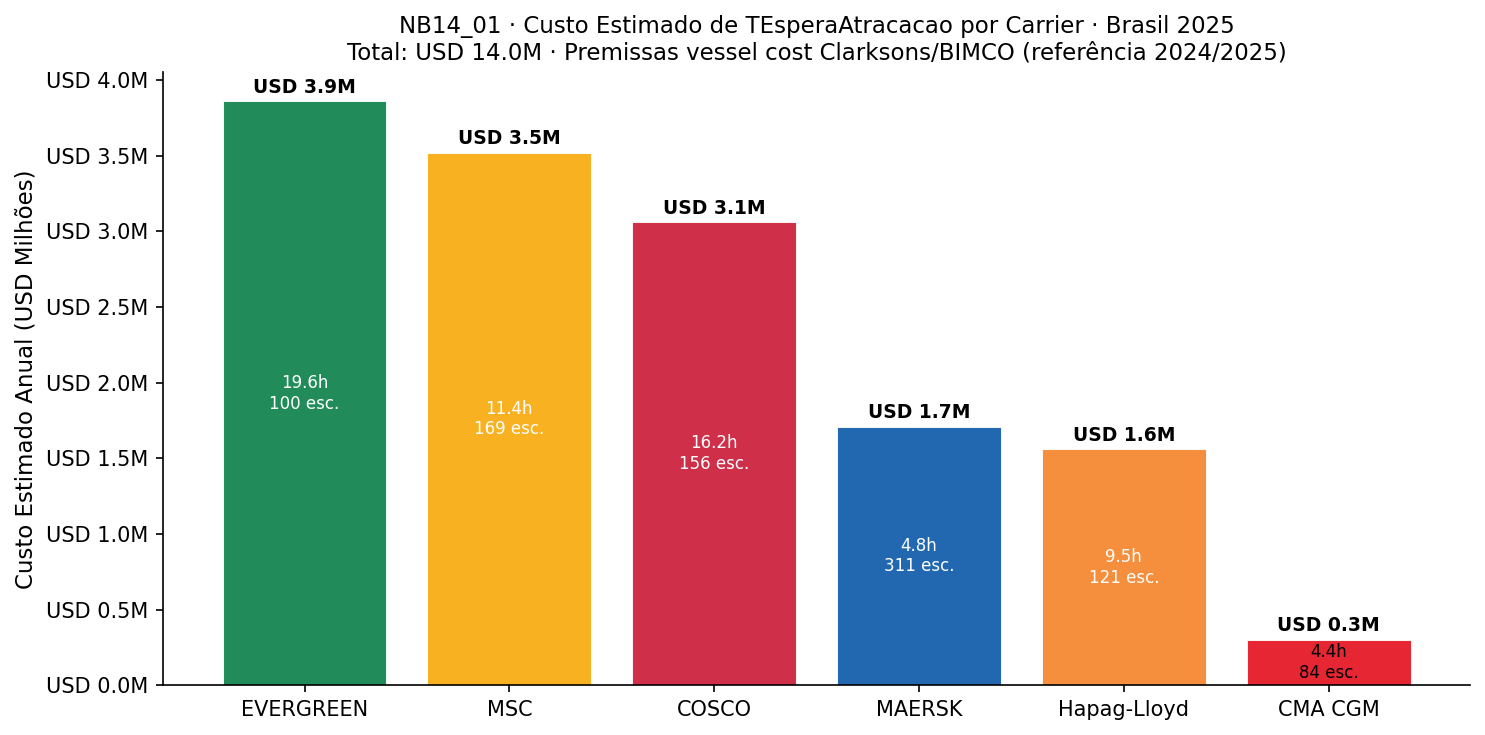

Salvo: nb14_01_custo_espera_carrier.png


In [5]:
# ── Figura nb14_01: Bar chart — custo anual por carrier ───────────────────
CARRIER_COLORS = {
    'MAERSK':      '#0052A5',
    'MSC':         '#F7A600',
    'CMA CGM':     '#E30613',
    'COSCO':       '#C8102E',
    'Hapag-Lloyd': '#F57F20',
    'EVERGREEN':   '#007B40',
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CARRIER_COLORS.get(c, '#888') for c in result['CARRIER']]
bars = ax.bar(result['CARRIER'], result['CustoAnual_MUSD'],
              color=colors, alpha=0.87, edgecolor='white', linewidth=0.5)

# Anotar barras
for bar, row in zip(bars, result.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'USD {row.CustoAnual_MUSD:.1f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{row.TEspera_h:.1f}h\n{row.N_Escalas} esc.',
            ha='center', va='center', fontsize=8, color='white' if bar.get_height() > 0.3 else 'black')

ax.set_ylabel('Custo Estimado Anual (USD Milhões)', fontsize=11)
ax.set_title(
    f'NB14_01 · Custo Estimado de TEsperaAtracacao por Carrier · Brasil 2025\n'
    f'Total: USD {total_musd:.1f}M · Premissas vessel cost Clarksons/BIMCO (referência 2024/2025)',
    fontsize=11
)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('USD %.1fM'))
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb14_01_custo_espera_carrier.png', dpi=150)
plt.show()
print('Salvo: nb14_01_custo_espera_carrier.png')

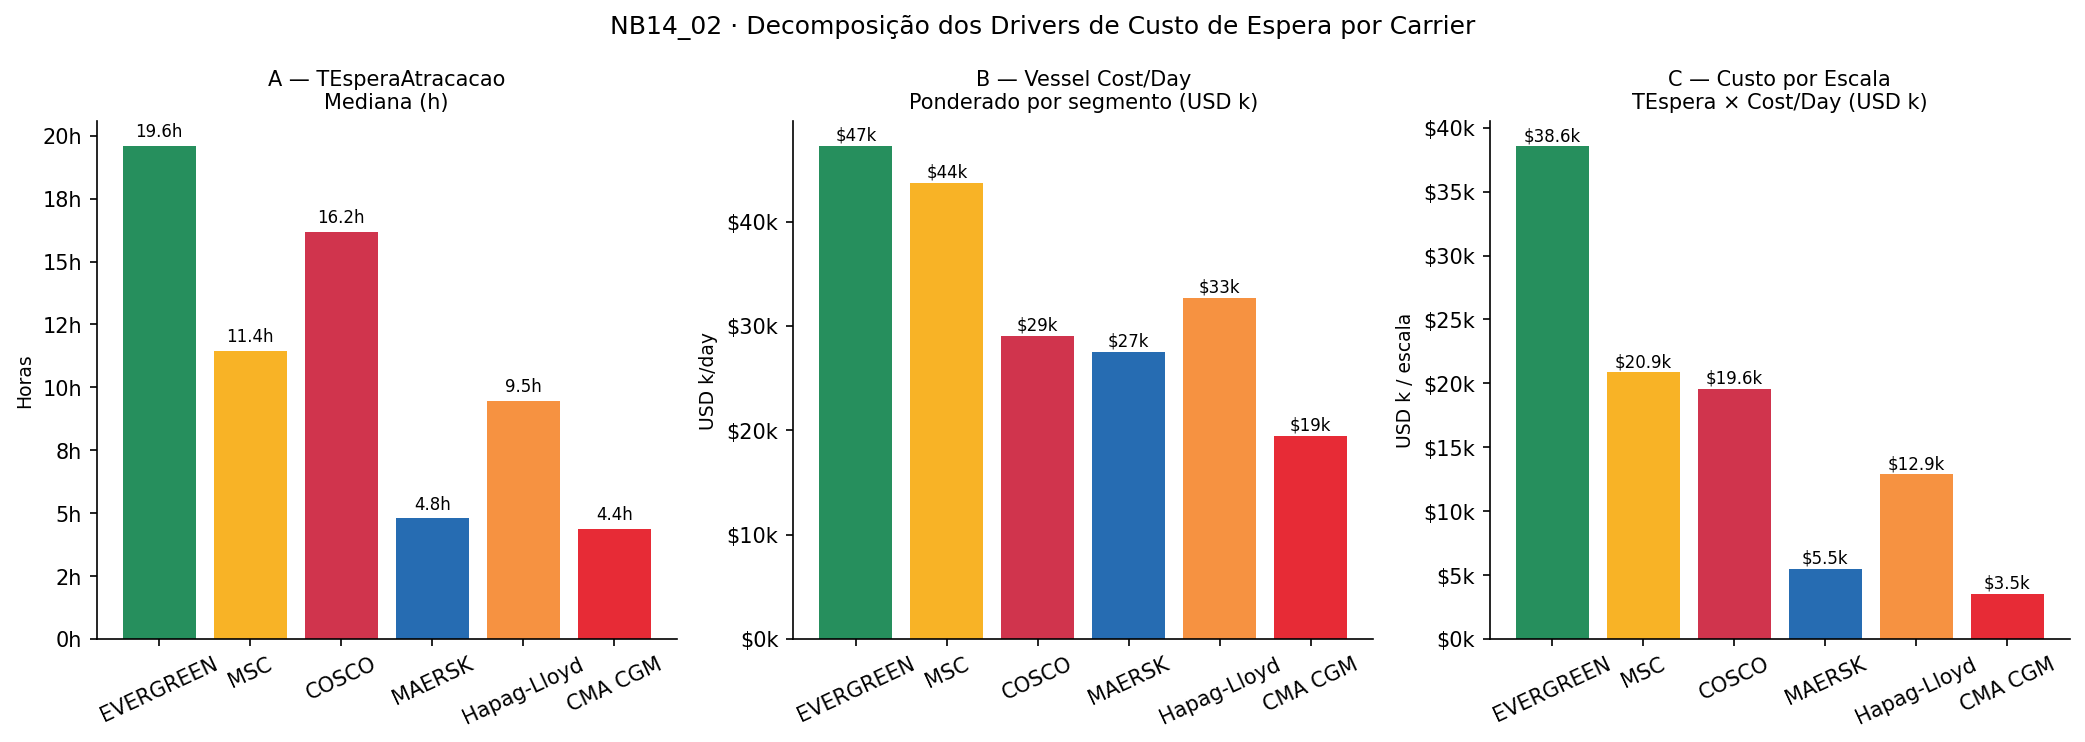

Salvo: nb14_02_decomposicao_drivers_custo.png


In [6]:
# ── Figura nb14_02: Decomposição — TEspera vs vessel_cost_day vs escalas ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

order = result['CARRIER'].tolist()
col_list = [CARRIER_COLORS.get(c, '#888') for c in order]

# Painel A: TEspera mediana
axes[0].bar(order, result['TEspera_h'], color=col_list, alpha=0.85)
axes[0].set_title('A — TEsperaAtracacao\nMediana (h)', fontsize=10)
axes[0].set_ylabel('Horas', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fh'))
for idx, val in enumerate(result['TEspera_h']):
    axes[0].text(idx, val + 0.2, f'{val:.1f}h', ha='center', va='bottom', fontsize=8)
axes[0].tick_params(axis='x', labelrotation=25)

# Painel B: Vessel cost/day ponderado
axes[1].bar(order, result['VesselCost_Day_USD'] / 1000, color=col_list, alpha=0.85)
axes[1].set_title('B — Vessel Cost/Day\nPonderado por segmento (USD k)', fontsize=10)
axes[1].set_ylabel('USD k/day', fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fk'))
for idx, val in enumerate(result['VesselCost_Day_USD']):
    axes[1].text(idx, val/1000 + 0.2, f'${val/1000:.0f}k', ha='center', va='bottom', fontsize=8)
axes[1].tick_params(axis='x', labelrotation=25)

# Painel C: Custo por escala
axes[2].bar(order, result['CustoPorEscala_USD'] / 1000, color=col_list, alpha=0.85)
axes[2].set_title('C — Custo por Escala\nTEspera × Cost/Day (USD k)', fontsize=10)
axes[2].set_ylabel('USD k / escala', fontsize=9)
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fk'))
for idx, val in enumerate(result['CustoPorEscala_USD']):
    axes[2].text(idx, val/1000 + 0.1, f'${val/1000:.1f}k', ha='center', va='bottom', fontsize=8)
axes[2].tick_params(axis='x', labelrotation=25)

fig.suptitle('NB14_02 · Decomposição dos Drivers de Custo de Espera por Carrier',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb14_02_decomposicao_drivers_custo.png', dpi=150)
plt.show()
print('Salvo: nb14_02_decomposicao_drivers_custo.png')

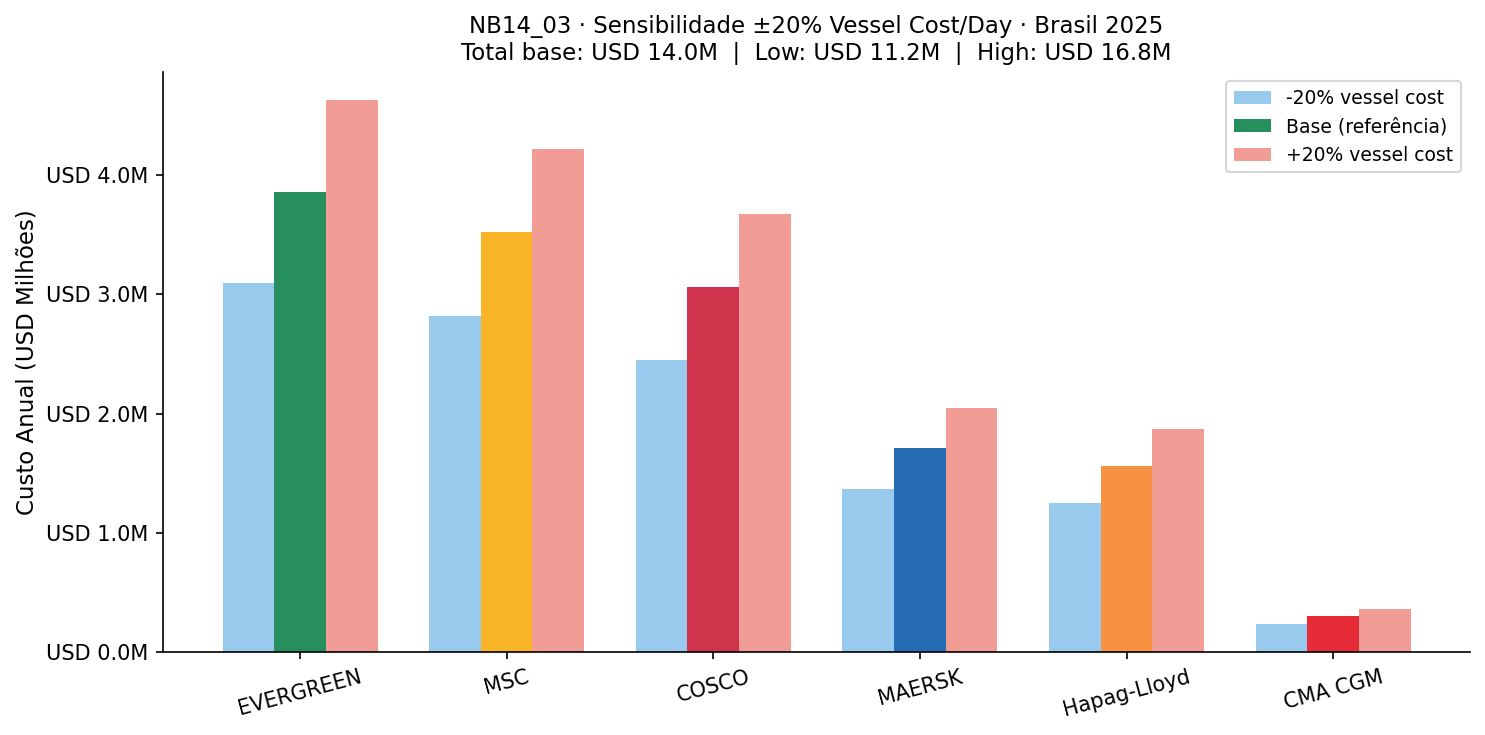

Salvo: nb14_03_sensibilidade_vessel_cost.png


In [7]:
# ── Figura nb14_03: Análise de sensibilidade ±20% vessel cost/day ─────────
# Custo anual com premissas -20% e +20%
result['CustoAnual_Low_MUSD']  = (result['CustoAnual_MUSD'] * 0.80).round(2)
result['CustoAnual_High_MUSD'] = (result['CustoAnual_MUSD'] * 1.20).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
x_s = range(len(result))
w_s = 0.25

ax.bar([i - w_s for i in x_s], result['CustoAnual_Low_MUSD'],  w_s,
       label='-20% vessel cost', color='#85C1E9', alpha=0.85)
ax.bar(x_s,                      result['CustoAnual_MUSD'],    w_s,
       label='Base (referência)', color=col_list, alpha=0.85)
ax.bar([i + w_s for i in x_s],  result['CustoAnual_High_MUSD'], w_s,
       label='+20% vessel cost', color='#E74C3C', alpha=0.55)

ax.set_xticks(list(x_s))
ax.set_xticklabels(result['CARRIER'], rotation=15)
ax.set_ylabel('Custo Anual (USD Milhões)', fontsize=11)
ax.set_title(
    f'NB14_03 · Sensibilidade ±20% Vessel Cost/Day · Brasil 2025\n'
    f'Total base: USD {total_musd:.1f}M  |  Low: USD {result["CustoAnual_Low_MUSD"].sum():.1f}M  '
    f'|  High: USD {result["CustoAnual_High_MUSD"].sum():.1f}M',
    fontsize=11
)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('USD %.1fM'))
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb14_03_sensibilidade_vessel_cost.png', dpi=150)
plt.show()
print('Salvo: nb14_03_sensibilidade_vessel_cost.png')

---
## 5 — Exportação

In [8]:
# ── Export ────────────────────────────────────────────────────────────────
export_cols = ['CARRIER','TEspera_h','N_Escalas','VesselCost_Day_USD',
               'CustoPorEscala_USD','CustoAnual_USD','CustoAnual_MUSD',
               'CustoAnual_Low_MUSD','CustoAnual_High_MUSD']
result[export_cols].to_csv(CSV_DIR + 'custo_espera_carrier_2025.csv',
                           index=False, encoding='utf-8-sig')
print('Salvo: custo_espera_carrier_2025.csv')

# Export segment mix + weighted cost
seg_export = seg_dist[['CARRIER'] + SEG_COLS + ['VesselCost_Day_USD']].copy()
seg_export.to_csv(CSV_DIR + 'mix_segmento_carrier_2025.csv',
                  index=False, encoding='utf-8-sig')
print('Salvo: mix_segmento_carrier_2025.csv')

print()
print('=== SUMÁRIO FINAL ===')
print(f'Carriers analisados: {len(result)}')
print(f'Total escalas cobertas: {result["N_Escalas"].sum():,}')
print(f'Custo total estimado (base):  USD {total_musd:.1f}M/ano')
print(f'Custo total estimado (low):   USD {result["CustoAnual_Low_MUSD"].sum():.1f}M/ano')
print(f'Custo total estimado (high):  USD {result["CustoAnual_High_MUSD"].sum():.1f}M/ano')
print()
print('Carrier com maior custo total:    ', result.iloc[0]['CARRIER'],
      f"→ USD {result.iloc[0]['CustoAnual_MUSD']:.1f}M")
print('Carrier com maior custo/escala:  ',
      result.loc[result['CustoPorEscala_USD'].idxmax(), 'CARRIER'],
      f"→ USD {result['CustoPorEscala_USD'].max():,.0f}/escala")
print('Carrier com menor TEspera:       ',
      result.loc[result['TEspera_h'].idxmin(), 'CARRIER'],
      f"→ {result['TEspera_h'].min():.2f}h mediana")

Salvo: custo_espera_carrier_2025.csv
Salvo: mix_segmento_carrier_2025.csv

=== SUMÁRIO FINAL ===
Carriers analisados: 6
Total escalas cobertas: 941
Custo total estimado (base):  USD 14.0M/ano
Custo total estimado (low):   USD 11.2M/ano
Custo total estimado (high):  USD 16.8M/ano

Carrier com maior custo total:     EVERGREEN → USD 3.9M
Carrier com maior custo/escala:   EVERGREEN → USD 38,588/escala
Carrier com menor TEspera:        CMA CGM → 4.37h mediana


---
## Declarações Obrigatórias — Limitações e Premissas

1. **Vessel cost/day são premissas públicas aproximadas** (referência Clarksons/BIMCO 2024/2025), não custos reais auditados. O custo efectivo varia com o tipo de contrato (timecharter vs voyage charter), mercado de afretamento spot e estrutura de custos fixos de cada empresa.

2. **TEsperaAtracacao é mediana** — 50% das escalas têm espera superior ao valor utilizado. O custo real (usando a média ou valores acima da mediana) seria materialmente mais elevado.

3. **Cobertura limitada a 2.2% das atracações LC identificadas via Vessels_Master** — os 6 carriers representam uma fracção do tráfego total de Longo Curso. Carriers não identificados (escalas sem IMO ou fora do Vessels_Master) não estão cobertos.

4. **Vessel cost/day varia com ciclo de mercado** — valores de 2024/2025 reflectem condições de mercado específicas. Em períodos de alta do mercado (ex: 2021-2022), os custos seriam substancialmente superiores.

5. **Análise de sensibilidade ±20%** (NB14_03) indica que a ordem de grandeza total está entre USD 6-9M para o intervalo conservador. A incerteza real pode ser maior dado o ponto 1.

6. **Distribuição de segmentos** baseada nas escalas identificadas (191 MAERSK, 157 MSC, etc.) — pode diferir do total real se a amostra identificada for não-representativa do mix completo do carrier no Brasil.